# Introduction: Quantum Ising Model on 1D Chain

The classical Ising model is a statistical model commonly taught in undergraduate physics. It is the first toy model to explain the phase transition between paramagnetism and ferromagnetism. The 1D and 2D model were solved respectively in 1925 and 1944 by Ising and Onsager. Let us start with the setup.

Consider a lattice $\Lambda$, on which each site $x$ has a spin $\sigma_x = \pm 1$. Bonds form between sites, let's denote the set of all bonds by $\mathcal{B} = \{(x, y): x, y \in \Lambda$ forms bonds $\}$. If site $x$ is bonded to site $y$, i.e. $(x, y) \in \mathcal{B}$, they have an interaction energy of $-\sigma_x \sigma_y$, otherwise they do not interact (that is we consider only the nearest-neighbour (NN) interaction). Then the Hamiltonian (total energy) of the system is simply is sum of all interaction energies:
$$ H_c = -\sum_{(x, y) \in \mathcal{B}} \sigma_x \sigma_y $$

From now on, we only consider an 1D chain, in which we can label sites from 1 to $L$, where $L$ is the length of the chain. We assume open boundary condition (OBC) so that $\sigma_{L+1} = \sigma_{1}$. Then the classical Hamiltonian can be written as:
$$ H_c = -\sum_{x = 1}^{L-1} \sigma_x \sigma_{x+1} $$

The quantum Ising model is nothing different, except we change each spin $\sigma_x$ to the spin-1/2 operator $\hat{\sigma}^{(3)}_x$*, which is the Pauli matrix that measures the spin along z-axis. At $T=0$, there is no thermal fluctuation, so in order to introduce disorder (to observe phase transition), we add a transverse field $g > 0$ along the x-axis, which interacts with each site at the energy cost of $-g \sigma_x$. This is called the transverse field Ising model (TFIM) and the Hamiltonian is:
$$ H_q = - \sum_{i = 1}^{L-1} \sigma_i^{(3)} \sigma_{i+1}^{(3)} - g\sum_{i=1}^{L} \sigma_i^{(1)} $$

Here, we also introduce a symmetry-breaking term, that breaks the $\mathbb{Z}_2$ symmetry of the Ising Hamiltonian. So the final Hamiltonian is:
$$ H = - \sum_{i = 1}^{L-1} \sigma_i^{(3)} \sigma_{i+1}^{(3)} - g\sum_{i=1}^{L} \sigma_i^{(1)} - h\sum_{i=1}^{L} \sigma_i^{(3)} $$

*: Rigorously speaking, $S^{(\alpha)} = \frac{\hbar}{2} \sigma^{(\alpha)}$ is the spin operator but we use the Pauli matrices for its simpler eigenvalues.

# Basics

## Construction of Hamiltonian Matrix

When we construct the Hamiltonian, we need a basis. Conventionally, we use the eigenbasis of $\sigma^{(3)}$, i.e. $\{|\uparrow\rangle, |\downarrow\rangle\}$ and represent them as $(1, 0)^T$ and $(0, 1)^T$ respectively. Under this basis, the identity ($I$), spin-x ($\sigma^{(1)}$) and spin-z ($\sigma^{(1)}$) operators are respectively:
$$ I = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}, ~~ \sigma^{(1)} = \begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix}, ~~ \sigma^{(3)} = \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}, ~~  $$

In [3]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from functools import reduce # for reducing a list of matrices to a single matrix
import h5py # for storing data

In [4]:
# Basis
up = sp.csr_matrix([1, 0])
down = sp.csr_matrix([0, 1])

# Single particle
I = sp.csr_matrix([[1, 0], [0, 1]])
sx = sp.csr_matrix([[0, 1], [1, 0]])
sz = sp.csr_matrix([[1, 0], [0, -1]])

If we have two sites, the new Hilbert space would be the tensor product of the two local Hilbert spaces. The dimension of the new space is $2 \times 2 = 4$, meaning the basis has four elements. They can be enumerated by all possible tensor products (i.e. Kronecker product under matrix representation) between the basis at site 1 and site 2:
$$ |\uparrow\rangle_1 |\uparrow\rangle_2 \mapsto (1, 0)^T \otimes (1, 0)^T = (1, 0, 0, 0)^T $$
$$ |\uparrow\rangle_1 |\downarrow\rangle_2 \mapsto (1, 0)^T \otimes (0, 1)^T = (0, 1, 0, 0)^T $$
$$ |\downarrow\rangle_1 |\uparrow\rangle_2 \mapsto (0, 1)^T \otimes (1, 0)^T = (0, 0, 1, 0)^T $$
$$ |\downarrow\rangle_1 |\downarrow\rangle_2 \mapsto (0, 1)^T \otimes (0, 1)^T = (0, 0, 0, 1)^T $$

Similarly, one can construct the spin operators of larger Hilbert space by tensor product (i.e. Kronecker product) between the spin operators of smaller Hilbert space. For example:
$$ \sigma_1^{(3)} = \sigma^{(3)} \otimes \mathbb{I} \mapsto \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix} \otimes \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix} = \begin{bmatrix} 1&&&\\&1&&\\&&-1&\\&&&-1 \end{bmatrix} $$
$$ \sigma_1^{(1)} = \sigma^{(1)} \otimes \mathbb{I} \mapsto \begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix} \otimes \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix} = \begin{bmatrix} &&1&\\&&&1\\1&&&\\&1&& \end{bmatrix} $$

Observe that the larger the Hilbert space, the sparser the spin operator matrix. That is why we use the csr format, which stores sparse matrix more efficiently and diagonalize the matrix much faster.

In [5]:
# Basis of two spin-1/2's
print("The new basis:")
print(sp.kron(up, up).toarray())
print(sp.kron(up, down).toarray())
print(sp.kron(down, up).toarray())
print(sp.kron(down, down).toarray())

# Example spin operators
print("\nThe new operators")
sz_1 = sp.kron(sz, I)
sx_1 = sp.kron(sx, I)
print(sz_1.toarray())
print(sx_1.toarray())

The new basis:
[[1 0 0 0]]
[[0 1 0 0]]
[[0 0 1 0]]
[[0 0 0 1]]

The new operators
[[ 1  0  0  0]
 [ 0  1  0  0]
 [ 0  0 -1  0]
 [ 0  0  0 -1]]
[[0 0 1 0]
 [0 0 0 1]
 [1 0 0 0]
 [0 1 0 0]]


Since we do not want to use sp.kron for L times, we can use the reduce function from functool package, and pass in sp.kron and a list of matrices. This will compute the tensor product of all matrices in the list in the listed order. Now, we can construct the Hamiltonian.

In [7]:
# Construct Hamiltonian
def quantum_ising_hamiltonian(L, g=0.0, h=0.0):
    """
    L (int): the length of chain
    g (float): the strength of transverse field
    """

    # Pauli matrix in sparse matrix format
    I = sp.csr_matrix([[1, 0], [0, 1]])
    sx = sp.csr_matrix([[0, 1], [1, 0]])
    sz = sp.csr_matrix([[1, 0], [0, -1]])

    # Size of Hilbert space = 2^L
    # Hamiltonian will have size = 2^L x 2^L
    H = sp.csr_matrix((2**L, 2**L))
    
    # NN interaction
    for i in range(L - 1):
        H -= reduce(sp.kron, [I]*i + [sz]*2 + [I]*(L-2-i))

    for i in range(L):
        term1 = reduce(sp.kron, [I]*i + [sx] + [I]*(L-1-i)) # Transverse field
        term2 = reduce(sp.kron, [I]*i + [sz] + [I]*(L-1-i)) # Symmetry-breaking
        H -= g * term1 + h * term2

    return H

In [8]:
H = quantum_ising_hamiltonian(L=2, g=1.0, h=0.0)
print(H)
print(H.toarray())

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 12 stored elements and shape (4, 4)>
  Coords	Values
  (0, 0)	-1.0
  (0, 1)	-1.0
  (0, 2)	-1.0
  (1, 0)	-1.0
  (1, 1)	1.0
  (1, 3)	-1.0
  (2, 0)	-1.0
  (2, 2)	1.0
  (2, 3)	-1.0
  (3, 1)	-1.0
  (3, 2)	-1.0
  (3, 3)	-1.0
[[-1. -1. -1.  0.]
 [-1.  1.  0. -1.]
 [-1.  0.  1. -1.]
 [ 0. -1. -1. -1.]]


## Saving data

Diagonalizing a matrix can take a really long time, so it is recommended to save your data in a well-structured way. Below is a template consisting of functions that save your computed data in .h5 format, so that you can retrieve your data whenever you need to do analysis with them. In particular, we save the eigenvalues and eigenvectors after diagonalizing the Hamiltonian, and name the data with the $L$ and $g$ at which it is computed. After running these functions, an .h5 file will be created in your current directory.

In [9]:
def save_ising_data(filename, L, g, h, energies, states):
    """
    Saves eigenvalues and eigenvectors into a structured HDF5 file.

    filename (str): set by yourself when you create the file, as you can see below
    """
    with h5py.File(filename, "a") as f:

        # A path to where your data is stored
        path = f"L_{L}/g_{g}/h_{h}"
        if path in f:
            del f[path]  # Delete old data and overwrite if already exists
        group = f.create_group(path)

        # Save the diagonalization data
        group.create_dataset("energies", data=energies, compression="gzip", compression_opts=4)
        group.create_dataset("states", data=states, compression="gzip", compression_opts=4)

        # Save metadata directly attached to this run
        group.attrs["L"] = L
        group.attrs["g"] = g
        group.attrs["h"] = h
        group.attrs["description"] = "ED_TFIM"

def print_metadata(name, obj):
    """Callback function to inspect each item in the HDF5 file."""
    # Indent based on hierarchy depth for readability
    depth = name.count('/')
    indent = "  " * depth
    
    if isinstance(obj, h5py.Group):
        print(f"{indent}📁 Group: {name}")
    elif isinstance(obj, h5py.Dataset):
        print(f"{indent}📄 Dataset: {name} (shape={obj.shape}, dtype={obj.dtype})")
    
    # Check and print any metadata attributes attached to this object
    if len(obj.attrs) > 0:
        for key, val in obj.attrs.items():
            print(f"{indent}    ⚙️ Attribute -> {key}: {val}")


# Here is how you read all the metadata and attributes
"""
# Open and inspect the file
filename = "quantum_ising_data.h5"
with h5py.File(filename, "r") as f:
    print(f"--- Metadata Structure for {filename} ---")
    # Print root-level attributes if any exist
    for key, val in f.attrs.items():
        print(f"Root Attribute -> {key}: {val}")
        
    # Recursively visit all paths
    f.visititems(print_metadata)
"""

'\n# Open and inspect the file\nfilename = "quantum_ising_data.h5"\nwith h5py.File(filename, "r") as f:\n    print(f"--- Metadata Structure for {filename} ---")\n    # Print root-level attributes if any exist\n    for key, val in f.attrs.items():\n        print(f"Root Attribute -> {key}: {val}")\n\n    # Recursively visit all paths\n    f.visititems(print_metadata)\n'

## Diagonalization

Here we use the Lancoz algorithm in the scipy package to diagonalize the Hamiltonian. By running the code below, you will diagonalize the Hamiltonian at inputs $L, g$ and $h$ and save the first $k$ eigenenergies and eigenvectors in an .h5 file.

In [10]:
# The same throughout the notebook
g_values = np.round(np.arange(0, 2.1, 0.2), 1) + 0.0 # To avoid round off small neg number to -0.0
h_values = np.round(np.arange(-1.0, 1.1, 0.2), 1) + 0.0 
k = 5
filename = "quantum_ising_data.h5"

In [112]:
L_values = [4, 6, 8]

for L in L_values:
    for g in g_values:
        for h in h_values:
            g = round(g, 1)
            h = round(h, 1)
            H = quantum_ising_hamiltonian(L=L, g=g, h=h)
            energies, states = spla.eigsh(H, k=k, which='SA')

            # Sort the energies and states
            sort_indices = np.argsort(energies)
            energies = energies[sort_indices]
            states = states[:, sort_indices]

            save_ising_data(filename, L=L, g=g, h=h, energies=energies, states=states)
            print(f"Saved data for L={L}, g={g}, h={h}")

Saved data for L=4, g=0.0, h=-1.0
Saved data for L=4, g=0.0, h=-0.8
Saved data for L=4, g=0.0, h=-0.6
Saved data for L=4, g=0.0, h=-0.4
Saved data for L=4, g=0.0, h=-0.2
Saved data for L=4, g=0.0, h=0.0
Saved data for L=4, g=0.0, h=0.2
Saved data for L=4, g=0.0, h=0.4
Saved data for L=4, g=0.0, h=0.6
Saved data for L=4, g=0.0, h=0.8
Saved data for L=4, g=0.0, h=1.0
Saved data for L=4, g=0.2, h=-1.0
Saved data for L=4, g=0.2, h=-0.8
Saved data for L=4, g=0.2, h=-0.6
Saved data for L=4, g=0.2, h=-0.4
Saved data for L=4, g=0.2, h=-0.2
Saved data for L=4, g=0.2, h=0.0
Saved data for L=4, g=0.2, h=0.2
Saved data for L=4, g=0.2, h=0.4
Saved data for L=4, g=0.2, h=0.6
Saved data for L=4, g=0.2, h=0.8
Saved data for L=4, g=0.2, h=1.0
Saved data for L=4, g=0.4, h=-1.0
Saved data for L=4, g=0.4, h=-0.8
Saved data for L=4, g=0.4, h=-0.6
Saved data for L=4, g=0.4, h=-0.4
Saved data for L=4, g=0.4, h=-0.2
Saved data for L=4, g=0.4, h=0.0
Saved data for L=4, g=0.4, h=0.2
Saved data for L=4, g=0.4, h

# Analysis of Data

## Phase diagram of 1D TFIM

To show the phase transition, we can plot the phase diagram, which is produced by drawing the spectrum of TFIM at the same $L$ against a given range of $g$. Note that at different $g$, the Hamiltonian is slightly different and so does the ground state energy. To put the spectrums at the same level, for each $g$, we shift the spectrum by $-E_0(g)$, i.e. the ground state energy. So the y-axis is the difference of energy between $i$-th excited state and the ground state ($E_i(g) - E_0(g)$) while the x-axis is the values of $g$.

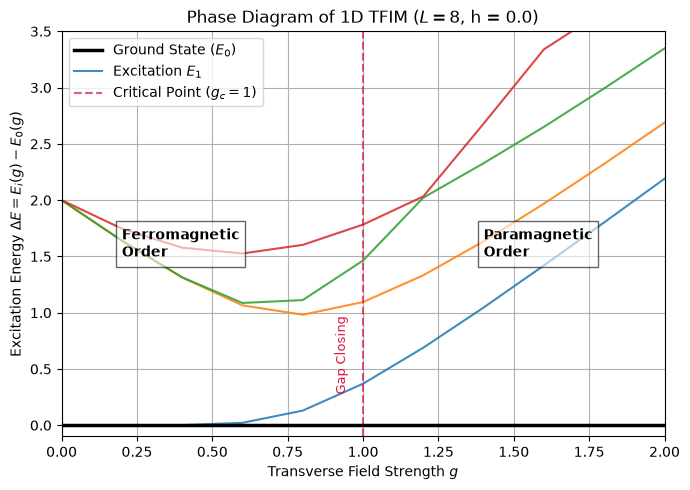

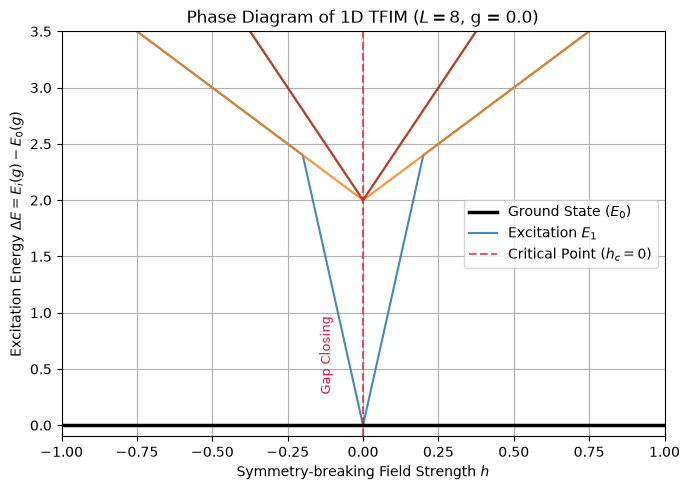

In [11]:
def plot_E_g(L, h):

    # Default settings
    # g_values = np.round(np.arange(0, 2.1, 0.2), 1) + 0.0

    # Retrieve energy for y_axis
    E_values = np.zeros((len(g_values), k))
    with h5py.File(filename, "r") as f:
        for idx, g in enumerate(g_values):
            for i in range(k):
                E_values[idx, i] = f[f"L_{L}/g_{g}/h_{h}/energies"][:][i]

    # Plot the results
    plt.figure(figsize=(7, 5))
    E_0 = E_values[:, 0] # Ground state energy across g
    for i in range(k):
        E_i = E_values[:, i] - E_0
        if i == 0:
            plt.plot(g_values, E_i, label="Ground State ($E_0$)", color="black", lw=2.5, zorder=3)
        else:
            plt.plot(g_values, E_i, label=f"Excitation $E_{i}$" if i==1 else "", lw=1.5, alpha=0.85)

    # Annotation
    plt.axvline(x=1.0, color="crimson", linestyle="--", alpha=0.7, label="Critical Point ($g_c=1$)") # transition pt.
    plt.text(0.95, 0.3, "Gap Closing", color="crimson", fontsize=9, rotation=90, ha='right') # transition pt.
    plt.text(0.2, 1.5, "Ferromagnetic\nOrder", fontsize=10, weight='bold', bbox=dict(facecolor='white', alpha=0.6)) # box
    plt.text(1.4, 1.5, "Paramagnetic\nOrder", fontsize=10, weight='bold', bbox=dict(facecolor='white', alpha=0.6)) # box

    # Labels and Styling
    plt.title(f"Phase Diagram of 1D TFIM ($L = {L}$, h = {h})")
    plt.xlabel("Transverse Field Strength $g$")
    plt.ylabel("Excitation Energy $\Delta E = E_i(g) - E_0(g)$")
    plt.xlim(0, 2.0)
    plt.ylim(-0.1, 3.5)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_E_h(L, g):

    # Default settings
    # h_values = np.round(np.arange(-1.0, 1.1, 0.2), 1) + 0.0

    # Retrieve energy for y_axis
    E_values = np.zeros((len(h_values), k))
    with h5py.File(filename, "r") as f:
        for idx, h in enumerate(h_values):
            for i in range(k):
                E_values[idx, i] = f[f"L_{L}/g_{g}/h_{h}/energies"][:][i]

    # Plot the results
    plt.figure(figsize=(7, 5))
    E_0 = E_values[:, 0] # Ground state energy across g
    for i in range(k):
        E_i = E_values[:, i] - E_0
        if i == 0:
            plt.plot(h_values, E_i, label="Ground State ($E_0$)", color="black", lw=2.5, zorder=3)
        else:
            plt.plot(h_values, E_i, label=f"Excitation $E_{i}$" if i==1 else "", lw=1.5, alpha=0.85)

    # Annotation
    if g <= 1:
        plt.axvline(x=0.0, color="crimson", linestyle="--", alpha=0.7, label="Critical Point ($h_c=0$)") # transition pt.
        plt.text(-0.1, 0.3, "Gap Closing", color="crimson", fontsize=9, rotation=90, ha='right') # transition pt.

    # Labels and Styling
    plt.title(f"Phase Diagram of 1D TFIM ($L = {L}$, g = {g})")
    plt.xlabel("Symmetry-breaking Field Strength $h$")
    plt.ylabel("Excitation Energy $\Delta E = E_i(g) - E_0(g)$")
    plt.xlim(-1.0, 1.0)
    plt.ylim(-0.1, 3.5)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_E_g(L=8, h=0.0)
plot_E_h(L=8, g=0.0)


## Ground state(s)

#### Exponential narrowing of first energy gap for $g < 1$

From the phase diagram, we see that there is a low-lying excited state that nearly overlaps with the ground state. This gap actually vanishes in the thermodynamic limit $L \to \infty$. Perturbative analysis can show that the gap decreases exponentially, as we show numerically in the plot below.

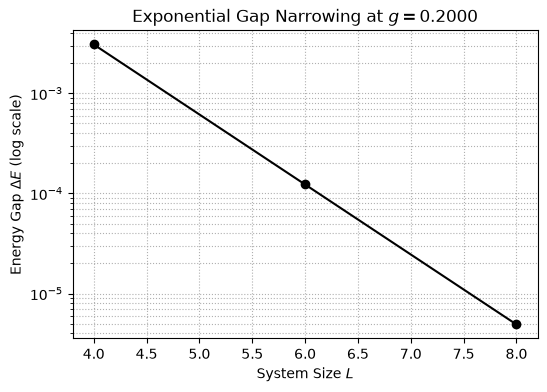

In [12]:
def plot_exp_law(L_values, g, h):
    """
    L_values (list): The axis of the plot
    g (float): Usually 0 < g < 1. Make sure it was precomputed
    h (float): Usually h=0. Make sure it was precomputed
    """
    gaps_1 = []
    with h5py.File("quantum_ising_data.h5", "r") as f:
        for L in L_values:
            E_0 = f[f"L_{L}/g_{g}/h_{h}/energies"][:][0]
            E_1 = f[f"L_{L}/g_{g}/h_{h}/energies"][:][1]
            gaps_1.append(E_1 - E_0)

    # Plot on a log-linear scale to observe the exponential decay
    plt.figure(figsize=(6, 4))
    plt.plot(L_values, gaps_1, 'o-', color='black')
    plt.yscale('log')
    plt.xlabel("System Size $L$")
    plt.ylabel("Energy Gap $\Delta E$ (log scale)")
    plt.title(f"Exponential Gap Narrowing at $g={g:.4f}$")
    plt.grid(True, which="both", ls=":")
    plt.show()

plot_exp_law(L_values=[4, 6, 8], g=0.2, h=0.0)

### Power law of first energy gap at $g = 1$

Extracted Dynamical Critical Exponent z = 0.9115 (Theoretical z = 1.0)


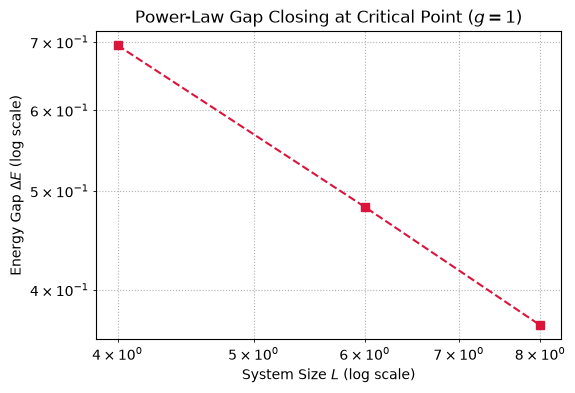

In [13]:
def plot_power_law(L_values, g, h):
    """
    L_values (list): The axis of the plot
    g (float): Usually g=1. Make sure it was precomputed
    h (float): Usually h=0. Make sure it was precomputed
    """
    gap_1 = []

    with h5py.File("quantum_ising_data.h5", "r") as f:
        for L in L_values:
            E_0 = f[f"L_{L}/g_{g}/h_{h}/energies"][:][0]
            E_1 = f[f"L_{L}/g_{g}/h_{h}/energies"][:][1]
            gap_1.append(E_1 - E_0)

    # Log-Log plot to extract the power-law exponent
    plt.figure(figsize=(6, 4))
    plt.loglog(L_values, gap_1, 's--', color='crimson')

    # Fit a straight line to the log data to extract the slope (z)
    slope, intercept = np.polyfit(np.log(L_values), np.log(gap_1), 1)
    print(f"Extracted Dynamical Critical Exponent z = {-slope:.4f} (Theoretical z = 1.0)")

    plt.xlabel("System Size $L$ (log scale)")
    plt.ylabel("Energy Gap $\Delta E$ (log scale)")
    plt.title("Power-Law Gap Closing at Critical Point ($g=1$)")
    plt.grid(True, which="both", ls=":")
    plt.show()

plot_power_law(L_values=[4, 6, 8], g=1.0, h=0.0)

- For $g < 1$, smaller $g$, small gap between GS & low-lying state and closes with exponential law
- At $g = 1$, the avoided crossing closes with power law
- For $g > 1$, gap opens

## Magnetization

#### Magnetization of GS

In [14]:
def get_M(L, g, h):
    """
    Constructs the sparse matrix for sigma^z acting on a single site.
    
    L (int): Length of the chain
    site_idx (int): The site of the chain at which you wnat to measure (0, 1, ..., L-1)
    """

    # Retrieve data
    filename = "quantum_ising_data.h5"
    with h5py.File(filename, "r") as f:
        # Access data directly like a dictionary
        psi_0 = (f[f"L_{L}/g_{g}/h_{h}/states"][:][:, 0]).reshape(-1, 1)  # Ensure it's a column vector for matrix operations
        psi_1 = (f[f"L_{L}/g_{g}/h_{h}/states"][:][:, 1]).reshape(-1, 1)

    # Approximate the infinite volume limit ground states (doubly degenerate & symmetry broken)
    # Otherwise the magnetization of finite size ground state is zero
    if 0 <= g <= 1 and h == 0.0:
        gs = 1/np.sqrt(2) * (psi_1 + psi_0)
    else:
        gs = psi_0

    # Magnetization at each site of the ground state
    M_list = []
    for i in range(L):
        # Construct spin operator
        temp = [sp.eye(2, format='csr')] * L
        temp[i] = sp.csr_matrix([[1, 0], [0, -1]])
        sz_i = reduce(sp.kron, temp)

        # Measurement
        M_list.append((gs.conj().T @ sz_i @ gs)[0, 0])
        M_avg = np.mean(np.array(M_list))

    return M_list, M_avg

In [15]:
get_M(L=8, g=0.2, h=0.0)

([np.float64(0.9797958971589885),
  np.float64(0.9944682789901422),
  np.float64(0.9948956433507423),
  np.float64(0.9949097204521096),
  np.float64(0.9949097204521095),
  np.float64(0.9948956433507424),
  np.float64(0.9944682789901422),
  np.float64(0.9797958971589884)],
 np.float64(0.9910173849879956))

- For $g < 1.0$, the magnetization at each site is approx. $\pm 1$, which is the eigenvalue of $\sigma^z$ (Ordered)
- For $g > 1.0$, the GS is unique and magnetization at each site is $0$ (Disordered)

#### Average magnetization of GS as a function of g or h

In [16]:
def plot_M_g(L=8, g_values=g_values, h=0.0):

    # Compute magnetization as function of g
    M_values = []
    for idx, g in enumerate(g_values):
        _, M_avg = get_M(L, g, h)
        M_values.append(np.abs(M_avg))

    # Compute theoretical magnetization from Onsager's solution
    g_fine = np.linspace(0.0, max(g_values), 500) # Fine grid for plotting
    M_theory = np.zeros_like(g_fine)
    M_theory[g_fine <= 1.0] = (1.0 - g_fine[g_fine <= 1.0]**2)**(1.8 / 8.0) # exponent beta = 1/8

    # Plot the results
    plt.figure(figsize=(6, 4))
    plt.scatter(g_values, M_values, color="blue", marker="x",
                label=r"Numerical values")
    plt.plot(g_fine, M_theory, color="black", linestyle="-", lw=2.5, 
             label=r"Theory: $(1 - g^2)^{1/8}$", zorder=5)
    plt.xlabel("Transverse Field Strength $g$")
    plt.ylabel("Magnetization")
    plt.title(f"Average magnetization of ground state at $h={h:.2f}$")
    plt.grid(True, which="both", ls=":")
    plt.legend()
    plt.show()

def plot_M_h(L=8, g=0.0, h_values=h_values):

    # Compute magnetization as function of g
    M_values = []
    for idx, h in enumerate(h_values):
        _, M_avg = get_M(L, g, h)
        M_values.append(M_avg)

    # Plot the results
    plt.figure(figsize=(6, 4))
    plt.scatter(h_values, M_values, color="blue", marker="x",
                label=r"Numerical values")
    plt.xlabel("Longitudinal Field Strength $h$")
    plt.ylabel("Magnetization")
    plt.title(f"Average magnetization of ground state at $g={g:.2f}$")
    plt.grid(True, which="both", ls=":")
    plt.legend()
    plt.show()

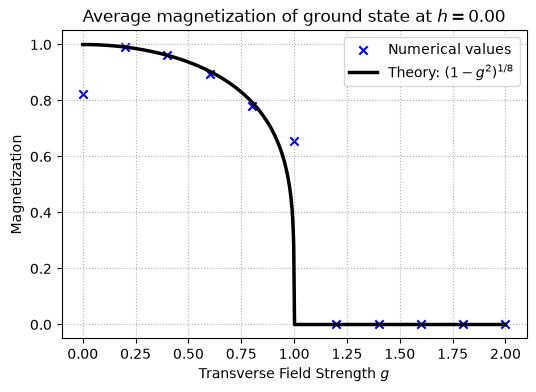

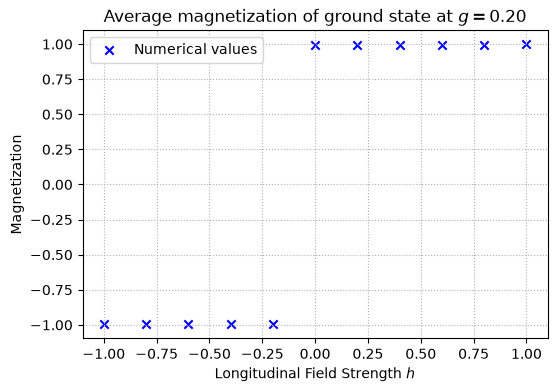

In [17]:
plot_M_g(L=8, g_values=g_values, h=0.0)
plot_M_h(L=8, g=0.2, h_values=h_values)

## Correlation function

In [22]:
def corr_op(L, site_idx):
    """
    Construct the correlation operator at site 0 and site "idx"
    """
    I = sp.csr_matrix([[1, 0], [0, 1]])
    op = [I] * L
    op[0] = op[site_idx] = sp.csr_matrix([[1, 0], [0, -1]])
    return reduce(sp.kron, op)

def plot_corr_site(L, g, h):

    # Retrieve ground state data
    with h5py.File("quantum_ising_data.h5", "r") as f:
        psi_0 = (f[f"L_{L}/g_{g}/h_{h}/states"][:][:, 0]).reshape(-1, 1)
        psi_1 = (f[f"L_{L}/g_{g}/h_{h}/states"][:][:, 1]).reshape(-1, 1)

    # Approximate the inf. vol. GS
    GS = (1/np.sqrt(2)) * (psi_0 - psi_1)
    # GS = psi_0

    # Compute the correlation function
    corr = []
    for i in range(1, L//2):
        corr.append((GS.conj().T @ corr_op(L, i) @ GS)[0, 0])

    # Plot the results
    plt.plot(range(1, L//2), corr, '-o')
    plt.title("Correlation across the chain")
    plt.xlabel("Site index")
    plt.ylabel("Correlation function")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()

    return corr

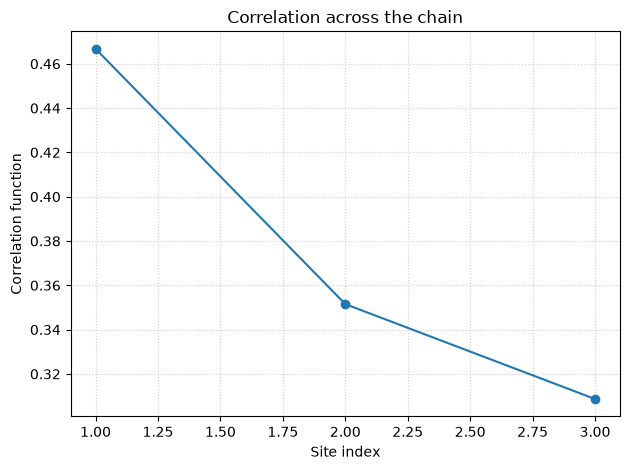

[np.float64(0.46673682031327857),
 np.float64(0.3515115388249431),
 np.float64(0.30869639963439677)]

In [23]:
plot_corr_site(8, 1.2, 0.0)

## Low-energy spectrum in momentum space

In [20]:
# Construct Hamiltonian
def H_mom(L, g=0.0, h=0.0):
    """
    L (int): the length of chain
    g (float): the strength of transverse field
    """

    # Pauli matrix in sparse matrix format
    I = sp.csr_matrix([[1, 0], [0, 1]])
    sx = sp.csr_matrix([[0, 1], [1, 0]])
    sz = sp.csr_matrix([[1, 0], [0, -1]])

    # Size of Hilbert space = 2^L
    # Hamiltonian will have size = 2^L x 2^L
    H = sp.csr_matrix((2**L, 2**L))
    
    # NN interaction
    for i in range(L - 1):
        H -= reduce(sp.kron, [I]*i + [sz]*2 + [I]*(L-2-i))

    # PBC, comment out to become OBC
    H -= reduce(sp.kron, [sz] + [I]*(L-2) + [sz])

    for i in range(L):
        term1 = reduce(sp.kron, [I]*i + [sx] + [I]*(L-1-i)) # Transverse field
        term2 = reduce(sp.kron, [I]*i + [sz] + [I]*(L-1-i)) # Symmetry-breaking
        H -= g * term1 + h * term2

    return H

Global ground-state energy shift: -15.322595151081
First 10 energies for the two lowest momentum sectors:
  k = 0.000000 (m = 0, dim = 352):
    [0.         0.13108693 1.04420954 2.20163929 3.06146746 4.105677
 4.13108693 4.87009143 5.78794118 5.91430097]
  k = 0.523599 (m = 1, dim = 335):
    [1.16636311 2.0528385  3.16636311 3.96577945 4.95951405 5.00998898
 5.16636311 5.60845908 6.42361567 6.63046472]


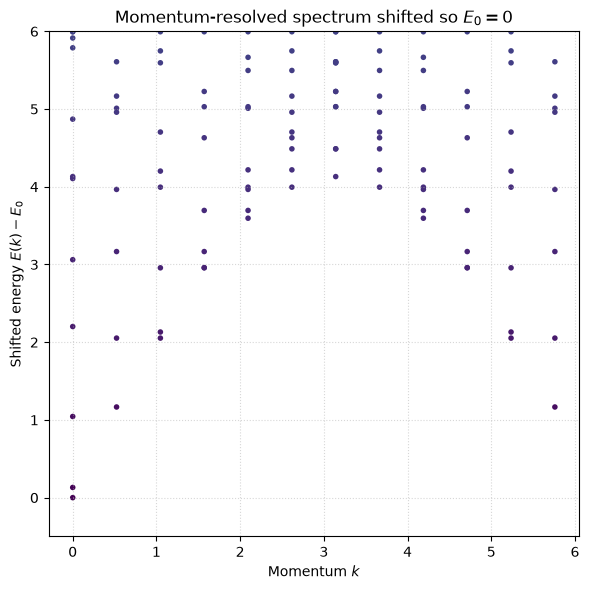

In [21]:
def translate_state(state, L, shift=1):
    """Cyclically translate a basis state by `shift` sites."""
    shift %= L
    bits = format(state, f"0{L}b")
    return int(bits[-shift:] + bits[:-shift], 2)


def translation_orbits(L):
    """Return translation orbits of the computational basis."""
    dim = 2**L
    seen = set()
    orbits = []

    for state in range(dim):
        if state in seen:
            continue

        orbit = []
        current = state
        while current not in orbit:
            orbit.append(current)
            current = translate_state(current, L)

        seen.update(orbit)
        orbits.append(orbit)

    return orbits


def momentum_basis_matrix(L, m):
    """Build the symmetry-adapted basis matrix for momentum sector m."""
    k = 2 * np.pi * m / L
    dim = 2**L
    rows = []
    cols = []
    data = []
    labels = []

    for orbit in translation_orbits(L):
        period = len(orbit)
        if (m * period) % L != 0:
            continue

        col = len(labels)
        labels.append(orbit[0])
        phase = np.exp(-1j * k * np.arange(period)) / np.sqrt(period)

        rows.extend(orbit)
        cols.extend([col] * period)
        data.extend(phase)

    Pk = sp.csr_matrix((data, (rows, cols)), shape=(dim, len(labels)), dtype=complex)
    return Pk, labels


def momentum_sector_spectrum(L, g=0.0, h=0.0):
    """Diagonalize each momentum block one at a time."""
    H_full = H_mom(L, g=g, h=h).tocsr().astype(complex)

    sector_data = []

    for m in range(L):
        Pk, labels = momentum_basis_matrix(L, m)
        if Pk.shape[1] == 0:
            continue

        Hk = (Pk.conjugate().T @ H_full @ Pk).toarray()
        eigvals = np.linalg.eigvalsh(Hk).real
        sector_data.append({
            "m": m,
            "k": 2 * np.pi * m / L,
            "dim": len(labels),
            "energies": np.sort(eigvals),
        })

    sector_data.sort(key=lambda item: item["k"])
    ground_energy = min(item["energies"][0] for item in sector_data)
    for item in sector_data:
        item["energies"] = item["energies"] - ground_energy

    return sector_data, ground_energy


def plot_shifted_momentum_spectrum(L, g=0.0, h=0.0):
    sector_data, ground_energy = momentum_sector_spectrum(L, g=g, h=h)

    print(f"Global ground-state energy shift: {ground_energy:.12f}")
    print("First 10 energies for the two lowest momentum sectors:")
    for idx, sector in enumerate(sector_data[:2]):
        print(f"  k = {sector['k']:.6f} (m = {sector['m']}, dim = {sector['dim']}):")
        print(f"    {sector['energies'][:10]}")

    k_points = np.concatenate([np.full(len(item["energies"]), item["k"]) for item in sector_data])
    energies_k = np.concatenate([item["energies"] for item in sector_data])

    plt.figure(figsize=(6, 6))
    plt.scatter(k_points, energies_k, s=16, c=energies_k, cmap="viridis", edgecolors="none")
    plt.xlabel(r"Momentum $k$")
    plt.ylabel(r"Shifted energy $E(k)-E_0$")
    plt.ylim([-0.5, 6])
    plt.title("Momentum-resolved spectrum shifted so $E_0 = 0$")
    plt.grid(True, linestyle=":", alpha=0.5)
    plt.tight_layout()
    plt.show()

    return sector_data, ground_energy


# Run the momentum decomposition using the current L, g, and h values.
sector_data, ground_energy = plot_shifted_momentum_spectrum(L=12, g=1.0, h=0.0)